# Module 3: Time Series Forecasting

## Objective
Teach forecasting foundations from classical to advanced machine learning methods.

### What is a Time Series?

A *time series* is an ordered sequence of observations ( y_t ) collected over time.
Examples: daily sales, hourly temperature, monthly revenue, etc.

Key characteristics:

* **Trend** – long-term increase/decrease.
* **Seasonality** – repeating short-term cycle (e.g., daily, weekly, yearly).
* **Noise / Irregularity** – random variations.
* **Stationarity** – statistical properties (mean, variance, autocovariance) constant over time.

---

## Core Models & Equations
- **ARIMA/SARIMAX**: \( y_t = c + \phi_1 y_{t-1} + ... + \epsilon_t + \Theta_1 \epsilon_{t-1} \)
- **ETS (Holt-Winters)**: \( y_t = (Level + Trend) * Seasonality + Error \)
- **STL Decomposition**: \( y_t = T_t + S_t + R_t \)
- **Prophet**: \( y(t) = g(t) + s(t) + h(t) + \epsilon_t \)
- **LSTM**: sequence model with memory cells capturing temporal dependencies
- **State-Space (UCM)**: latent structure with transition and observation equations
- **XGBoost**: tree-based regression with lag features
- **AutoML**: automated model selection and stacking

## Teaching Tips
1. Start with time series fundamentals (stationarity, autocorrelation).
2. Show step-by-step model fitting (Statsmodels → Prophet → TensorFlow).
3. Include OOT validation (train/test split chronologically).
4. Emphasize uncertainty interpretation using CRPS and prediction intervals.
5. Showcase visualization of Actual vs Forecast using Plotly.

## Model Comparison Table
| Type | Example | Strengths | Weaknesses | Use Cases | Library |
|------|----------|------------|-------------|------------|----------|
| Classical | ARIMA/SARIMAX | Interpretable, fast | Assumes linearity | Trend/Seasonality | Statsmodels |
| Decomposition | STL | Clear diagnostics | Not direct forecast | Diagnostics | Statsmodels |
| Additive/Trend | Prophet | Handles holidays | Less flexible | Sales, traffic | Prophet |
| Deep Learning | LSTM/GRU | Captures non-linearity | Data-hungry | Energy | TensorFlow |
| Probabilistic | BSTS | Quantifies uncertainty | Heavy compute | Finance | PyMC |
| Multivariate | VAR | Inter-series | Dimensionality issues | Macroeconomics | Statsmodels |
| Tree-Based | XGBoost | Non-stationary features | Lag design needed | Hybrid | XGBoost |
| AutoML | AutoTS | Automated | Less control | Rapid Prototyping | PyCaret |

## Validation Visualization
Use OOT validation for all models:
- Train/Test split chronologically
- Plot Actual vs Predicted with CI bands
- Evaluate MAE, RMSE, and CRPS.

## Key Time Series Forecasting Solutions - Practical Applications:
As it is encouraged to experimentation with multiple models, tuning hyperparameters, and combining forecasts. - This notebook covers all classical, decomposition, Prophet, deep learning, probabilistic, multivariate, tree-based, and AutoML forecasting techniques.

---

# **TIME SERIES FORECASTING — Use Case**

---

#  **Step 0: Install Necessary Packages**


In [8]:
!pip install pandas numpy matplotlib seaborn statsmodels prophet scikit-learn xgboost keras tensorflow



---

# **Step 1: Create Synthetic Time-Series Data**

* Monthly sales for 6 years
* Clear trend + seasonality + noise


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2018-01-01", end="2023-12-01", freq="ME")
n = len(dates)

trend = np.linspace(200, 500, n)                         # upward trend
seasonality = 40 * np.sin(2 * np.pi * np.arange(n) / 12) # annual cycle
noise = np.random.normal(0, 20, n)                       # business noise

sales = trend + seasonality + noise

df = pd.DataFrame({"Date": dates, "Sales": sales})
df = df.set_index("Date")

df.head()


,Sales
Date,
2018-01-31,209.934283
2018-02-28,221.520428
2018-03-31,256.166215
2018-04-30,283.317740
2018-05-31,247.100806




---

# **Step 2: Plot the Data**


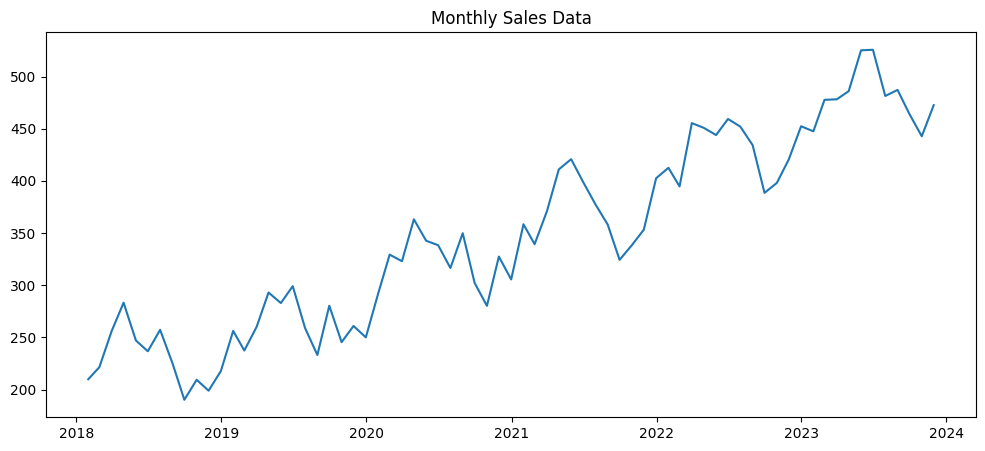

In [3]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Sales"])
plt.title("Monthly Sales Data")
plt.show()



---

# **Step 3: Decompose Trend & Seasonality**


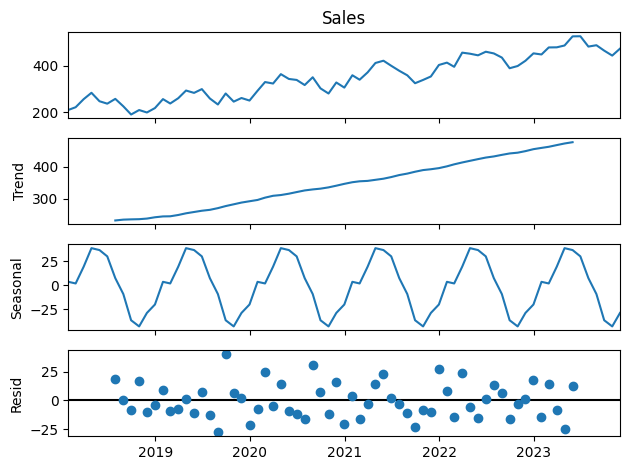

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df["Sales"], model="additive")
decomp.plot()
plt.show()



---

# **Step 4: Train–Test Split**

Last 12 months → test set.


In [5]:
train = df.iloc[:-12]
test = df.iloc[-12:]




---

# **Step 5: ARIMA Model**


d:\Python Code\APA_Mod3\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
d:\Python Code\APA_Mod3\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
d:\Python Code\APA_Mod3\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


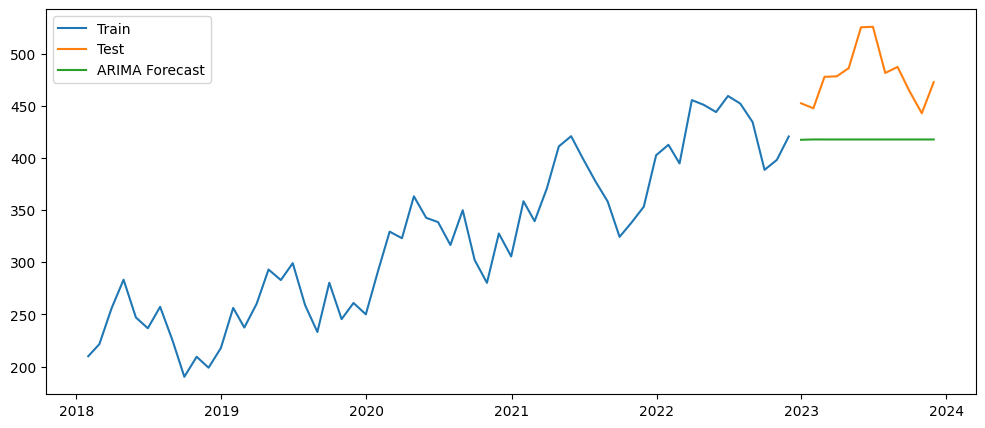

In [6]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["Sales"], order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=12)

plt.figure(figsize=(12,5))
plt.plot(train["Sales"], label="Train")
plt.plot(test["Sales"], label="Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.show()




---

# **Step 6: Holt-Winters Exponential Smoothing**



d:\Python Code\APA_Mod3\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


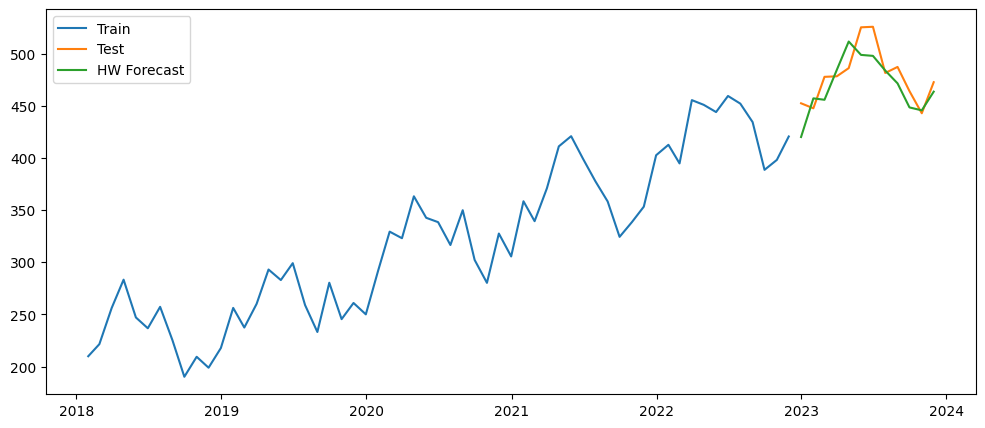

In [9]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(12)

plt.figure(figsize=(12,5))
plt.plot(train["Sales"], label="Train")
plt.plot(test["Sales"], label="Test")
plt.plot(hw_forecast, label="HW Forecast")
plt.legend()
plt.show()




---

# **Step 7: Prophet Model**

Prophet requires specific formatting.



d:\Python Code\APA_Mod3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
12:48:06 - cmdstanpy - INFO - Chain [1] start processing
12:48:09 - cmdstanpy - INFO - Chain [1] done processing
d:\Python Code\APA_Mod3\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


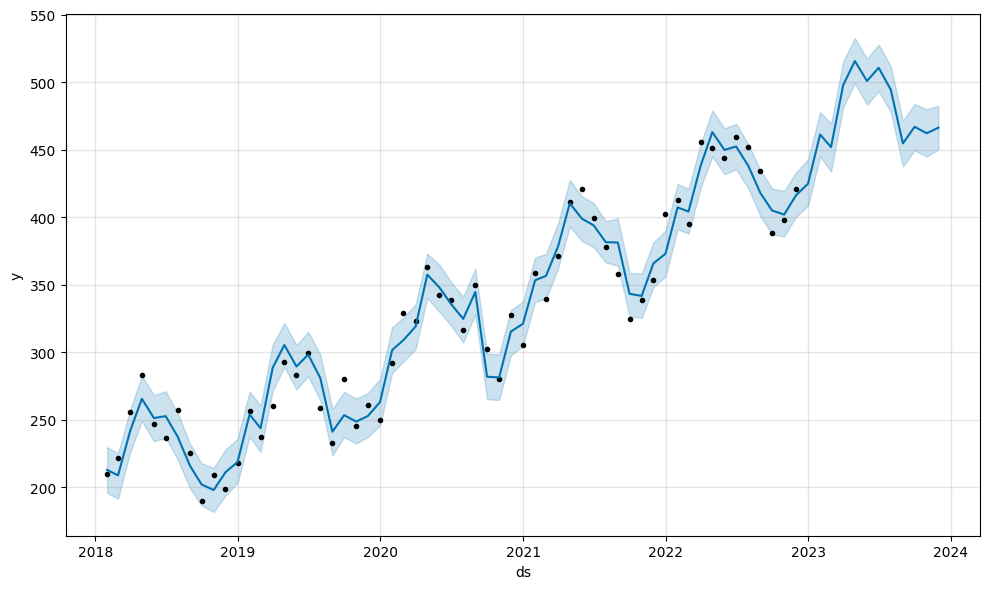

In [10]:

from prophet import Prophet

prophet_df = train.reset_index().rename(columns={"Date":"ds", "Sales":"y"})

m = Prophet(yearly_seasonality=True)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=12, freq="M")
forecast = m.predict(future)

prophet_forecast = forecast.set_index("ds")["yhat"][-12:]

m.plot(forecast)
plt.show()




---

# **Step 8: Machine Learning Model (XGBoost)**

Create lag features:



In [11]:

ml_df = df.copy()
ml_df["lag1"] = ml_df["Sales"].shift(1)
ml_df["lag2"] = ml_df["Sales"].shift(2)
ml_df = ml_df.dropna()

train_ml = ml_df.iloc[:-12]
test_ml = ml_df.iloc[-12:]

X_train = train_ml[["lag1", "lag2"]]
y_train = train_ml["Sales"]

X_test = test_ml[["lag1", "lag2"]]
y_test = test_ml["Sales"]




Train model:



In [12]:

from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)




Plot:



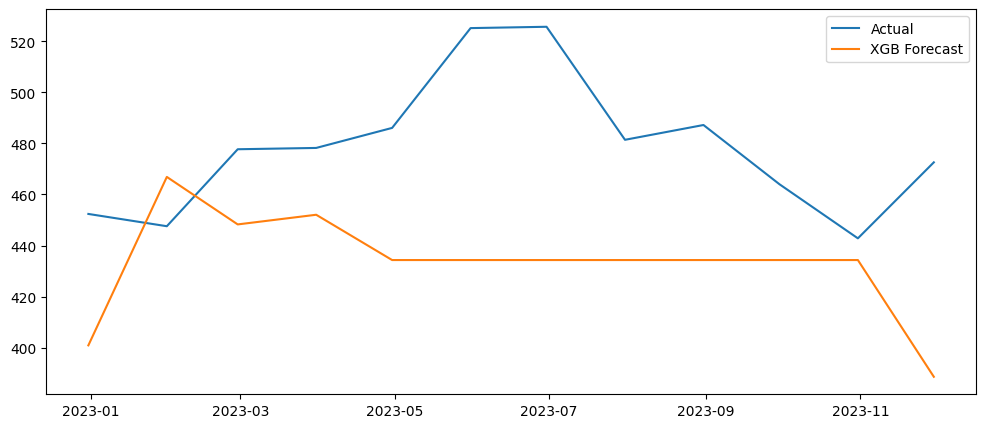

In [13]:

plt.figure(figsize=(12,5))
plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, xgb_pred, label="XGB Forecast")
plt.legend()
plt.show()




---

# **Step 9: Deep Learning Forecast (LSTM)**

Requires scaled sequences.



In [15]:

from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

sequence = 12
X, y = [], []

for i in range(sequence, len(scaled)):
    X.append(scaled[i-sequence:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)

X_train_dl = X[:-12]
X_test_dl = X[-12:]
y_train_dl = y[:-12]




Build LSTM:



In [16]:

from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, activation="tanh", input_shape=(sequence, 1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=12, verbose=0)


d:\Python Code\APA_Mod3\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)




Forecast:



In [17]:

lstm_pred_scaled = model.predict(X_test_dl)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step




---

# **Step 10: Compare All Models**



In [18]:

comparison = pd.DataFrame({
    "Actual": test["Sales"].values,
    "ARIMA": arima_forecast.values,
    "HoltWinters": hw_forecast.values,
    "Prophet": prophet_forecast.values,
    "XGBoost": xgb_pred,
    "LSTM": lstm_pred.flatten()
}, index=test.index)

comparison


,Actual,ARIMA,HoltWinters,Prophet,XGBoost,LSTM
Date,,,,,,
2022-12-31,452.368045,417.382500,420.056397,424.783958,400.881927,456.322754
2023-01-31,447.559372,417.717429,457.089346,461.152636,466.874084,460.036499
2023-02-28,477.715392,417.682077,455.734859,451.897012,448.266479,462.358093
2023-03-31,478.228602,417.685809,484.380595,497.692520,452.051758,468.635895
2023-04-30,486.075868,417.685415,511.551316,515.598233,434.306122,470.231415
2023-05-31,525.177247,417.685456,498.742905,500.802639,434.306122,473.063904
2023-06-30,525.696229,417.685452,497.816521,510.607565,434.306122,479.703522
2023-07-31,481.416940,417.685452,483.752944,494.347116,434.306122,485.019073
2023-08-31,487.213515,417.685452,471.451345,454.597537,434.306122,487.497040




Plot:



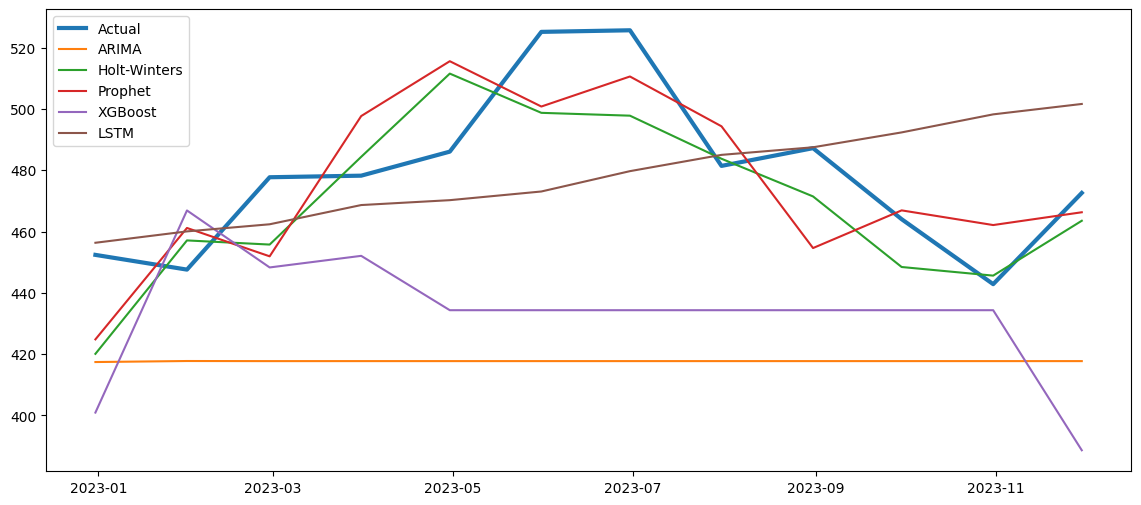

In [19]:

plt.figure(figsize=(14,6))
plt.plot(comparison["Actual"], label="Actual", linewidth=3)
plt.plot(comparison["ARIMA"], label="ARIMA")
plt.plot(comparison["HoltWinters"], label="Holt-Winters")
plt.plot(comparison["Prophet"], label="Prophet")
plt.plot(comparison["XGBoost"], label="XGBoost")
plt.plot(comparison["LSTM"], label="LSTM")
plt.legend()
plt.show()




---

# **Step 11: Accuracy Metrics**



In [20]:

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

for col in ["ARIMA","HoltWinters","Prophet","XGBoost","LSTM"]:
    rmse = np.sqrt(mean_squared_error(comparison["Actual"], comparison[col]))
    mape = mean_absolute_percentage_error(comparison["Actual"], comparison[col]) * 100
    print(f"{col}: RMSE={rmse:.2f}, MAPE={mape:.2f}%")



ARIMA: RMSE=65.81, MAPE=12.46%
HoltWinters: RMSE=19.08, MAPE=3.36%
Prophet: RMSE=21.09, MAPE=3.99%
XGBoost: RMSE=55.45, MAPE=9.95%
LSTM: RMSE=29.32, MAPE=4.70%


---

## 🛠️ **5. Real-World Challenges**

| Challenge              | Solution                                                                |
| ---------------------- | ----------------------------------------------------------------------- |
| Missing data           | Forward/backfill, linear interpolation, or Prophet’s built-in handling. |
| Outliers               | Cap/floor limits, winsorization, or robust loss models.                 |
| Multiple frequencies   | Resample to consistent interval (daily, weekly).                        |
| Feature scaling        | Apply per-series scaling for neural nets.                               |
| Large number of series | Use Darts multiseries models or PyCaret AutoML loops.                   |

---


## 🧾 **7. Key Takeaways**

| Concept        | When to Use                                                |
| -------------- | ---------------------------------------------------------- |
| ARIMA/SARIMAX  | Strong autocorrelation, stationary data, limited features. |
| Holt-Winters   | Smooth trend/seasonality, few data points.                 |
| Prophet        | Business data with holidays/changepoints.                  |
| LSTM/GRU       | Complex, nonlinear, long sequences.                        |


---

## 📚 **References **

* Prophet changepoints & holidays – Meta/Prophet Docs
* Darts unified API – Unit8 Docs
* Optuna optimization – Optuna Docs
* PyCaret Time Series AutoML – PyCaret Docs
* CRPS definition – Wikipedia / properscoring package
